# Importar DataBase

In [463]:
import pandas as pd
import numpy as np
database = pd.read_csv('Titanic-Dataset.csv')

# Interpretacion de los datos

1. Leer y entender el database
2. Detectar la variable objetivo(y)

In [464]:
database.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Limpieza de datos

1. Eliminar valores duplicados.ok
2. Eliminar valores nulos.ok
3. Eliminar columnas irrelevantes.ok
4. Modificar variables categoricas a numericas.ok
5. Escalar valores si hace falta.ok
6. Extraer la variable y
7. Extraer la variable x.ok

In [465]:
from sklearn.preprocessing import StandardScaler
database = database.drop_duplicates()
database = database.dropna()

datos_x = database.drop(columns=['PassengerId','Name','Ticket','Cabin','Survived'])
datos_x = pd.get_dummies(datos_x, dtype=int)
datos_x = StandardScaler().fit_transform(datos_x)

datos_y = database['Survived']

In [466]:
#datos_x.head()
#datos_y.head()
datos_x.shape
#datos_y.shape

(183, 10)

# Division de datos en Train y Test

In [467]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(datos_x,datos_y,test_size=0.2,train_size=0.8,random_state=1)
print(f"x train: {x_train.shape}, x test: {x_test.shape} \t y train: {y_train.shape}, y test: {y_test.shape}")

x train: (146, 10), x test: (37, 10) 	 y train: (146,), y test: (37,)


### Convertir los datos en tensores para Pytorch

In [468]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, TensorDataset, DataLoader

t_x_train = torch.from_numpy(x_train).float().to('cpu')
t_x_test = torch.from_numpy(x_test).float().to('cpu')

t_y_train = torch.from_numpy(y_train.to_numpy()).long().to('cpu')
t_y_test = torch.from_numpy(y_test.to_numpy()).long().to('cpu')

# Redimensionar los tensores de (n) a (n,1)
#t_y_train = t_y_train[:,None]
#t_y_test = t_y_test[:,None]

print(f"x train: {t_x_train.shape}, x test: {t_x_test.shape} \t y train: {t_y_train.shape}, y test: {t_y_test.shape}")

x train: torch.Size([146, 10]), x test: torch.Size([37, 10]) 	 y train: torch.Size([146]), y test: torch.Size([37])


In [469]:
print(t_y_train.shape)

torch.Size([146])


### Empaquetar datos en Train y Test

In [470]:
train_dataset = TensorDataset(t_x_train,t_y_train)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_dataset = TensorDataset(t_x_test,t_y_test)

print(type(train_dataset))
print(train_dataset[0])

<class 'torch.utils.data.dataset.TensorDataset'>
(tensor([-0.3723, -0.2355, -0.7230, -0.6317, -0.6328, -0.9625,  0.9625,  1.3474,
        -0.1051, -1.3158]), tensor(1))


# Red Neuronal

### Definir la estructura de la red
1. numero de entradas -> 10
2. capas ocultas -> ?? probaremos con 2
3. numero de salidas -> 2 (multiclase) vive/muere

In [471]:
# Extraer el numero de entradas para una variable
n_entradas = len(t_x_train[0])
print(n_entradas)

10


In [472]:
class RedNeuronal(nn.Module):

    def __init__(self,n_entradas):
        super().__init__()
        self.capa_entrada = nn.Linear(n_entradas,8)
        self.capa_oculta1 = nn.Linear(8,6)
        self.capa_oculta2 = nn.Linear(6,4)
        self.capa_salida = nn.Linear(4,2)
    
    def forward(self,inputs):
        pred_1 = torch.relu(self.capa_entrada(inputs))
        pred_2 = torch.relu(self.capa_oculta1(pred_1))
        pred_3 = torch.relu(self.capa_oculta2(pred_2))
        pred_final = self.capa_salida(pred_3)
        return pred_final

### Definir hiperparametros
1. epochs
2. learning rate
3. batch size -> de momento esto queda pendiente. no hay DataLoader
4. estatus_print

In [473]:
epochs = 200
lr = 0.001
estatus_print = 100

### Crear Objetos
1. Modelo
2. funcion de perdida
3. optimizador

In [474]:
torch.manual_seed(42)
np.random.seed(42)

model = RedNeuronal(n_entradas=n_entradas)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

### Bucle de entrenamiento
1. Forward (predicción)  
2. Calcular pérdida (loss)  
3. Backward ((loss)gradientes)  
4. Actualizar pesos (optimizer step) 
5. Limpiar gradientes 
6. Captura de registros(historico)
7. Prints
8. Calcular accuracy (precision) TESTING

In [475]:
historico = []

for epoch in range(1,epochs +1):

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = loss_fn(y_pred,y_batch)
        loss.backward()
        optimizer.step()

    if epoch % estatus_print == 0:
        print(f"Epoch: {epoch}, Loss: {round(loss.item(),4)}")

        # Usar esta funcion para que no se tenga en cuenta en Training
        # Calculamos accuracy (precison de aciertos)
        with torch.no_grad():
            y_pred = model(t_x_test)
            y_pred_class = torch.argmax(y_pred,dim=1)
            accuracy = ((y_pred_class == t_y_test).float().mean() * 100).round()
            #accuracy = correctos / float(len(t_y_test)) * 100

            if epoch % estatus_print == 0:
                print(f"Accuracy: {accuracy}")

            
            '''MEDIR LA ACCURACY DE TRAIN Y TEST PARA VER COMO PREDICE EL MODELO.
            EN ESTE CASO PARAECE HABER OVERFITING. '''
            # y_pred_train = model(t_x_train)
            # y_pred_train_class = torch.argmax(y_pred_train, dim=1)
            # acc_train = (y_pred_train_class == t_y_train).float().mean()

            # y_pred_test = model(t_x_test)
            # y_pred_test_class = torch.argmax(y_pred_test, dim=1)
            # acc_test = (y_pred_test_class == t_y_test).float().mean()


                
        # Guardar todos los datos
        historico.append({
            'Epoch':epoch,
            'Loss':round(loss.item(),4),
            'Accuracy':round(accuracy.item(),4),
        })
# print(acc_train)
# print(acc_test)

historico = pd.DataFrame(historico)

Epoch: 100, Loss: 0.2526
Accuracy: 70.0
Epoch: 200, Loss: 0.2099
Accuracy: 68.0


### Visualizacion del resultado
1. Perdida
2. Precision

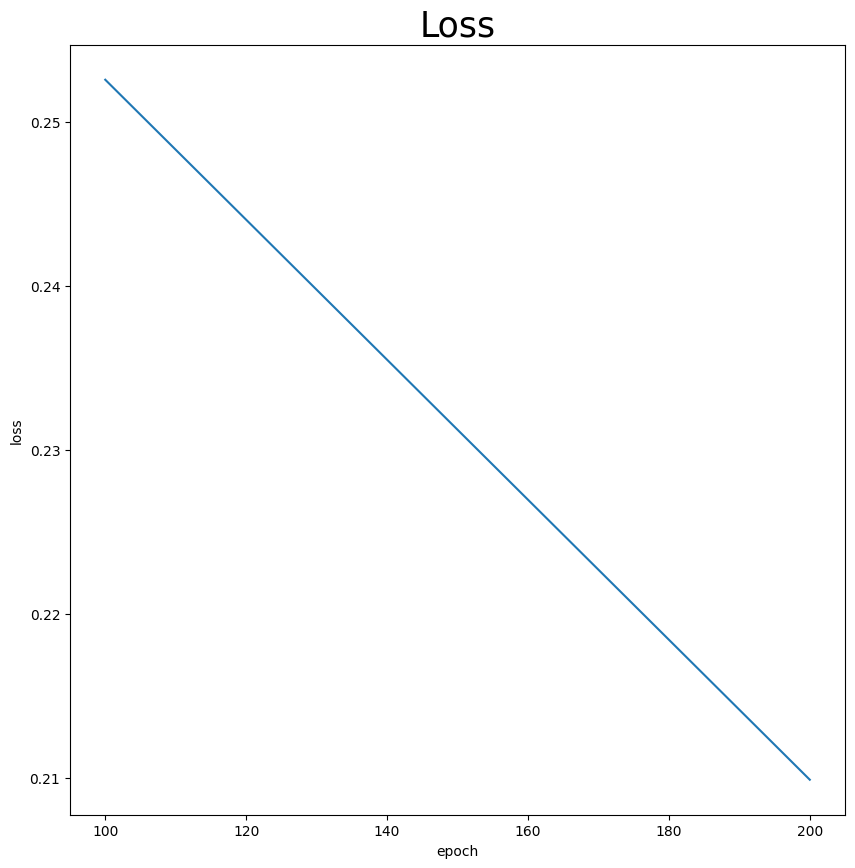

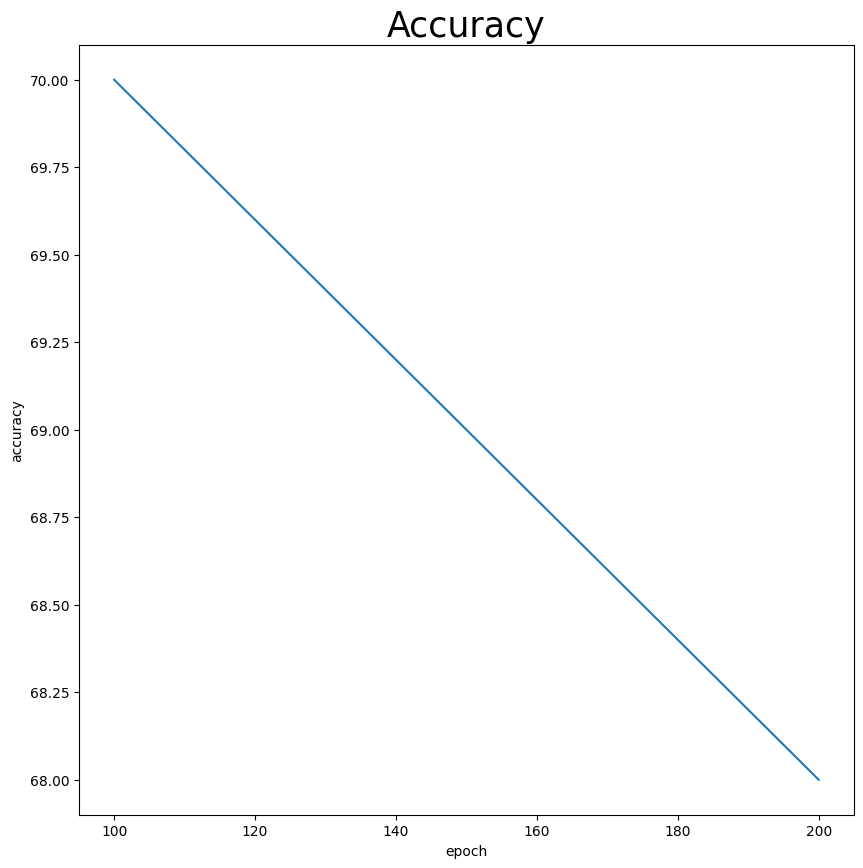

In [476]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(historico['Epoch'],historico['Loss'])
plt.title('Loss',fontsize=25)
plt.xlabel(xlabel='epoch')
plt.ylabel(ylabel='loss')
plt.show()

plt.figure(figsize=(10,10))
plt.plot(historico['Epoch'],historico['Accuracy'])
plt.title('Accuracy',fontsize=25)
plt.xlabel(xlabel='epoch')
plt.ylabel(ylabel='accuracy')
plt.show()


